In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


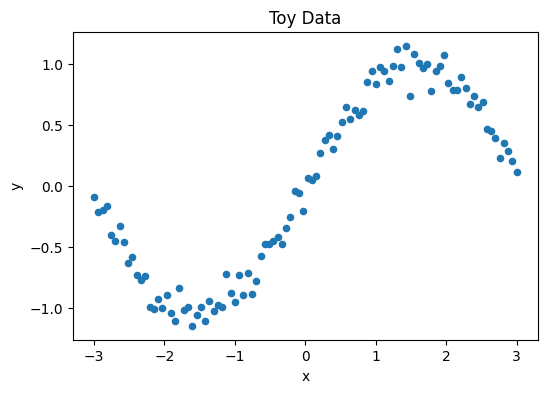

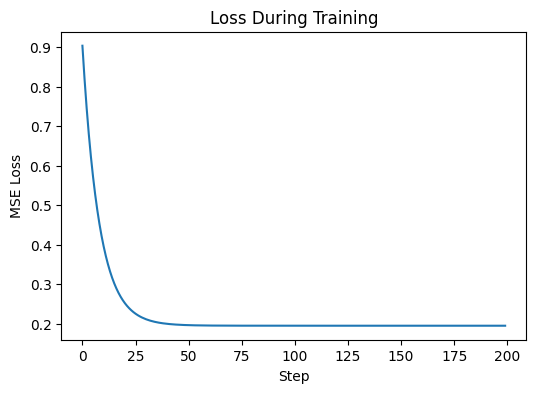

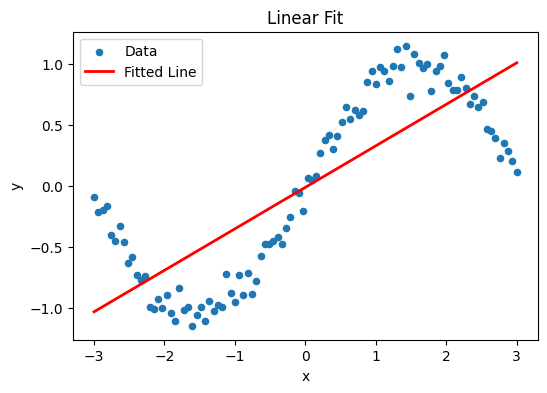

In [2]:
# Generate the toy data
np.random.seed(42)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the data
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20)
plt.title("Toy Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Initialise w and b
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.01
losses = []

# Gradient Descent
for step in range(200):

    # Predictions
    y_hat = w * x + b

    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters
    w -= lr * dw
    b -= lr * db

# Plot the loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data", s=20)
plt.plot(x, w * x + b, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

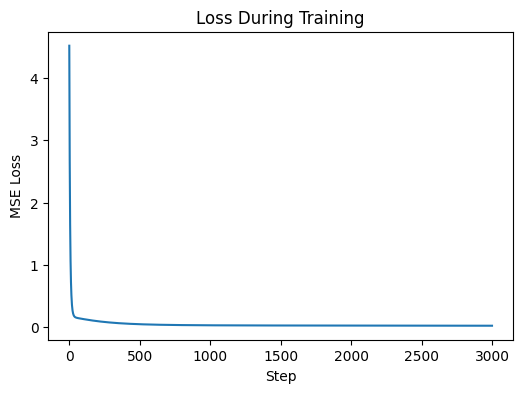

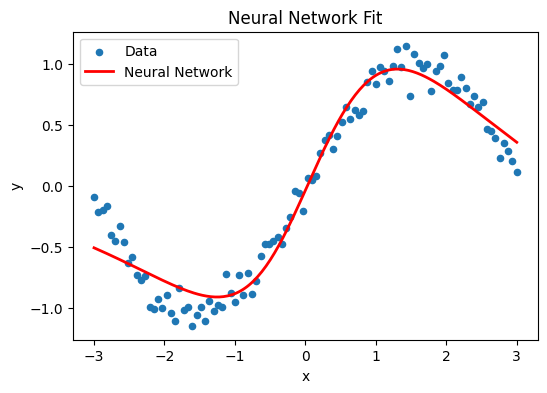

In [5]:
# Reshape the data
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Initialise parameters
np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
losses = []

# Training
for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot final fit
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Data")

x_plot = np.linspace(-3, 3, 200).reshape(-1,1)
z1 = x_plot @ W1 + b1
h = np.tanh(z1)
y_plot = h @ W2 + b2

plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Neural Network")
plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

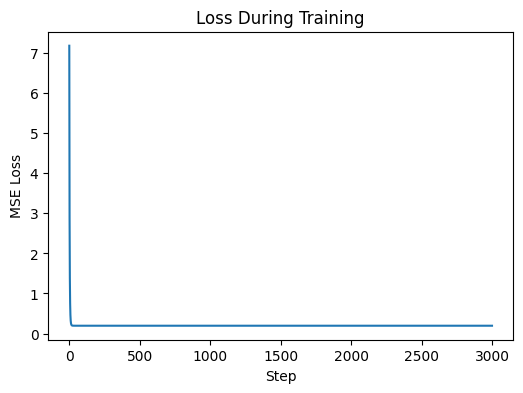

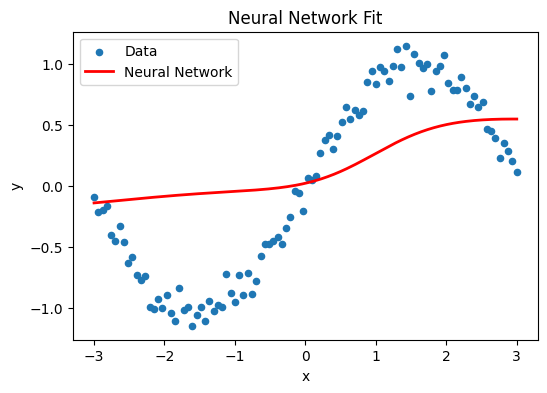

In [6]:
# Reshape the data
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Initialise parameters
np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
losses = []

# Training
for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = z1

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot final fit
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Data")

x_plot = np.linspace(-3, 3, 200).reshape(-1,1)
z1 = x_plot @ W1 + b1
h = np.tanh(z1)
y_plot = h @ W2 + b2

plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Neural Network")
plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()